In [ ]:
import yfinance as yf
import pandas as pd

In [ ]:
apple = yf.Ticker("AAPL")

In [ ]:
info = apple.info
info

In [ ]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META", 
           "TSLA", "NVDA", "JPM", "JNJ", "PG"]

In [21]:
datos = []

for ticker in tickers:
    empresa = yf.Ticker(ticker)
    info = empresa.info
    datos.append(info)

In [23]:
df = pd.DataFrame(datos)
df.shape

(10, 187)

In [25]:
columnas = ['symbol', 'shortName', 'sector', 'trailingPE', 'forwardPE', 
            'priceToBook', 'debtToEquity', 'profitMargins', 
            'returnOnEquity', 'revenueGrowth', 'earningsGrowth']

df = df[columnas]
df

,symbol,shortName,sector,trailingPE,forwardPE,priceToBook,debtToEquity,profitMargins,returnOnEquity,revenueGrowth,earningsGrowth
0,AAPL,Apple Inc.,Technology,38.174335,32.815243,43.432507,79.548,0.27152,1.41471,0.166,0.218
1,MSFT,Microsoft Corporation,Technology,22.936270,19.891580,6.904280,30.271,0.39342,0.34014,0.183,0.234
2,GOOGL,Alphabet Inc.,Communication Services,27.244852,24.513006,9.039328,20.026,0.37919,0.38885,0.218,0.820
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,29.311829,24.805996,5.970360,53.300,0.12224,0.24285,0.166,0.748
4,META,"Meta Platforms, Inc.",Communication Services,24.334910,18.420841,6.969994,35.608,0.32837,0.32930,0.331,0.624
5,TSLA,"Tesla, Inc.",Consumer Cyclical,370.690920,158.194290,18.621730,18.738,0.03946,0.04901,0.158,0.083
6,NVDA,NVIDIA Corporation,Technology,32.256880,16.494099,26.141266,6.555,0.62966,1.14288,0.852,2.145
7,JPM,JP Morgan Chase & Co.,Financial Services,16.106750,14.059830,2.620912,NaN,0.33936,0.16465,0.127,0.172
8,JNJ,Johnson & Johnson,Healthcare,29.777521,20.164024,7.617608,67.730,0.21834,0.26416,0.099,-0.529
9,PG,Procter & Gamble Company (The),Consumer Defensive,21.497074,20.820147,6.370608,67.651,0.19162,0.31112,0.074,0.058


In [31]:
df.to_csv('data/raw/empresas_raw.csv', index=False)

In [33]:
df = pd.read_csv('data/raw/empresas_raw.csv')
df

,symbol,shortName,sector,trailingPE,forwardPE,priceToBook,debtToEquity,profitMargins,returnOnEquity,revenueGrowth,earningsGrowth
0,AAPL,Apple Inc.,Technology,38.174335,32.815243,43.432507,79.548,0.27152,1.41471,0.166,0.218
1,MSFT,Microsoft Corporation,Technology,22.936270,19.891580,6.904280,30.271,0.39342,0.34014,0.183,0.234
2,GOOGL,Alphabet Inc.,Communication Services,27.244852,24.513006,9.039328,20.026,0.37919,0.38885,0.218,0.820
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,29.311829,24.805996,5.970360,53.300,0.12224,0.24285,0.166,0.748
4,META,"Meta Platforms, Inc.",Communication Services,24.334910,18.420841,6.969994,35.608,0.32837,0.32930,0.331,0.624
5,TSLA,"Tesla, Inc.",Consumer Cyclical,370.690920,158.194290,18.621730,18.738,0.03946,0.04901,0.158,0.083
6,NVDA,NVIDIA Corporation,Technology,32.256880,16.494099,26.141266,6.555,0.62966,1.14288,0.852,2.145
7,JPM,JP Morgan Chase & Co.,Financial Services,16.106750,14.059830,2.620912,NaN,0.33936,0.16465,0.127,0.172
8,JNJ,Johnson & Johnson,Healthcare,29.777521,20.164024,7.617608,67.730,0.21834,0.26416,0.099,-0.529
9,PG,Procter & Gamble Company (The),Consumer Defensive,21.497074,20.820147,6.370608,67.651,0.19162,0.31112,0.074,0.058


In [35]:
df.isnull().sum()

symbol            0
shortName         0
sector            0
trailingPE        0
forwardPE         0
priceToBook       0
debtToEquity      1
profitMargins     0
returnOnEquity    0
revenueGrowth     0
earningsGrowth    0
dtype: int64

In [37]:
df.describe()

,trailingPE,forwardPE,priceToBook,debtToEquity,profitMargins,returnOnEquity,revenueGrowth,earningsGrowth
count,10.000000,10.000000,10.000000,9.000000,10.000000,10.000000,10.00000,10.000000
mean,61.233134,35.017906,13.368859,42.158556,0.291318,0.464767,0.23740,0.457300
std,108.904931,43.589963,12.685686,25.778080,0.164648,0.444459,0.22715,0.711261
min,16.106750,14.059830,2.620912,6.555000,0.039460,0.049010,0.07400,-0.529000
25%,23.285930,18.788526,6.504026,20.026000,0.198300,0.248177,0.13475,0.105250
50%,28.278340,20.492086,7.293801,35.608000,0.299945,0.320210,0.16600,0.226000
75%,31.637040,24.732748,16.226129,67.651000,0.369233,0.376672,0.20925,0.717000
max,370.690920,158.194290,43.432507,79.548000,0.629660,1.414710,0.85200,2.145000


In [39]:
df.fillna(df['debtToEquity'].median(), inplace=True)

,symbol,shortName,sector,trailingPE,forwardPE,priceToBook,debtToEquity,profitMargins,returnOnEquity,revenueGrowth,earningsGrowth
0,AAPL,Apple Inc.,Technology,38.174335,32.815243,43.432507,79.548,0.27152,1.41471,0.166,0.218
1,MSFT,Microsoft Corporation,Technology,22.936270,19.891580,6.904280,30.271,0.39342,0.34014,0.183,0.234
2,GOOGL,Alphabet Inc.,Communication Services,27.244852,24.513006,9.039328,20.026,0.37919,0.38885,0.218,0.820
3,AMZN,"Amazon.com, Inc.",Consumer Cyclical,29.311829,24.805996,5.970360,53.300,0.12224,0.24285,0.166,0.748
4,META,"Meta Platforms, Inc.",Communication Services,24.334910,18.420841,6.969994,35.608,0.32837,0.32930,0.331,0.624
5,TSLA,"Tesla, Inc.",Consumer Cyclical,370.690920,158.194290,18.621730,18.738,0.03946,0.04901,0.158,0.083
6,NVDA,NVIDIA Corporation,Technology,32.256880,16.494099,26.141266,6.555,0.62966,1.14288,0.852,2.145
7,JPM,JP Morgan Chase & Co.,Financial Services,16.106750,14.059830,2.620912,35.608,0.33936,0.16465,0.127,0.172
8,JNJ,Johnson & Johnson,Healthcare,29.777521,20.164024,7.617608,67.730,0.21834,0.26416,0.099,-0.529
9,PG,Procter & Gamble Company (The),Consumer Defensive,21.497074,20.820147,6.370608,67.651,0.19162,0.31112,0.074,0.058


In [41]:
df.isnull().sum()

symbol            0
shortName         0
sector            0
trailingPE        0
forwardPE         0
priceToBook       0
debtToEquity      0
profitMargins     0
returnOnEquity    0
revenueGrowth     0
earningsGrowth    0
dtype: int64

In [44]:
df.to_csv('data/processed/empresas_clean.csv', index=False)

In [46]:
git add .
git commit -m "Fase 2: limpieza de datos, tratamiento de nulos"
git push

SyntaxError: invalid syntax (3562543870.py, line 1)

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

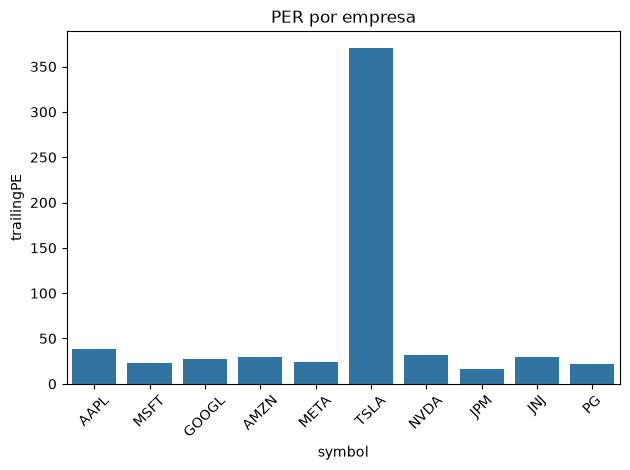

In [50]:
sns.barplot(data=df, x='symbol', y='trailingPE')
plt.title('PER por empresa')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='symbol', ylabel='trailingPE'>

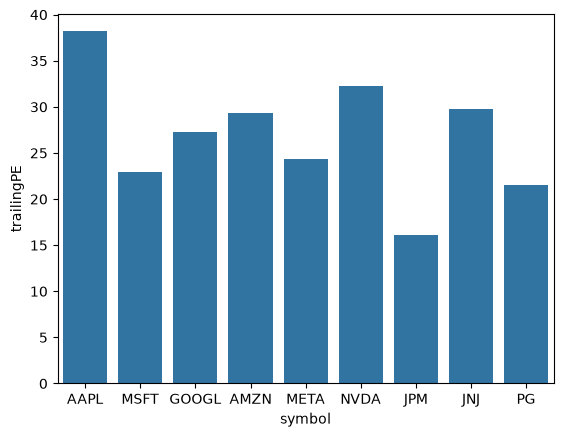

In [52]:
sns.barplot(data=df[df['symbol'] != 'TSLA'], x='symbol', y='trailingPE')

<Axes: xlabel='symbol', ylabel='trailingPE'>

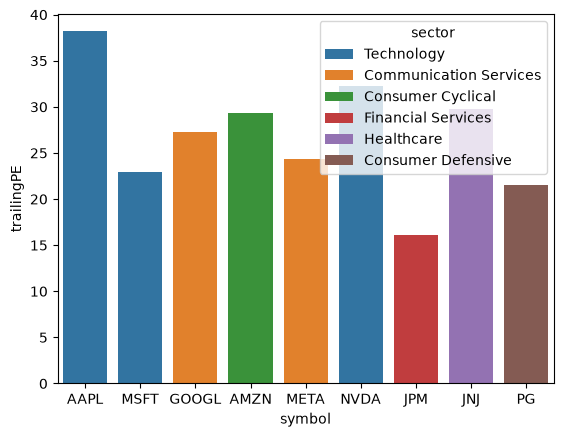

In [54]:
sns.barplot(data=df[df['symbol'] != 'TSLA'], x='symbol', y='trailingPE', hue='sector')

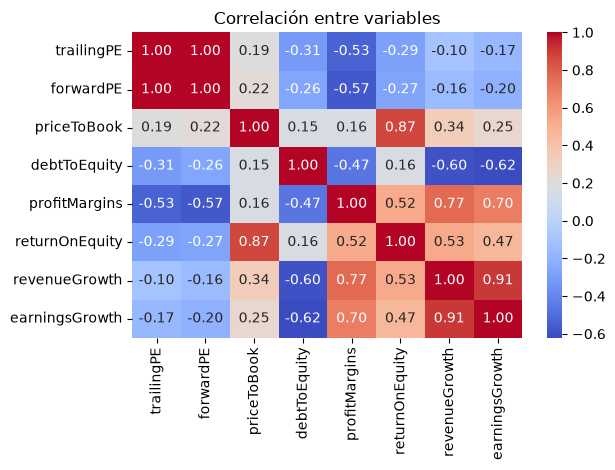

In [55]:
sns.heatmap(df[['trailingPE', 'forwardPE', 'priceToBook', 'debtToEquity', 
                'profitMargins', 'returnOnEquity', 'revenueGrowth', 'earningsGrowth']].corr(), 
            annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlación entre variables')
plt.tight_layout()
plt.show()